In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.animation import FuncAnimation


# 2D advection #

@autor:     Dario Hug

@date:      02.12.2024

Solve the 2D advection problem with both the CIR and the CTU method:

- on a quadratic, periodic grid, with a 2D gaussian as initial condition
- evolve the solution for multiple passings of the domain
- create an animation comparing the two methods
- discuss if and how the solution diffuses numerically depending on the direction of motion and the resolution

## Courant-Isaacson-Rees Method ##

$ Ca = \frac{a \Delta t}{\Delta x} $ 

$ Cb = \frac{b \Delta t}{\Delta y} $ 

$ \rho_j^{n+1} = \rho_{j,l}^n - Ca (\rho_{j,l}^n - \rho_{j-1,l}^n) - Cb(\rho_{j,l}^n - \rho_{j, l-1}^n) $ 

In [24]:
def CIR(rho, ca, cb, N):
    rho_new = rho.copy()
    for j in range(N):
        for l in range(N):
            rho_new[j][l] = rho[j][l] - ca * (rho[j][l] - rho[j-1][l]) - cb * (rho[j][l] - rho[j][l-1])
    return rho_new

## Corner Transport Upwind Method ##

$ \rho_{j,l}^{n+1} = (1-Ca)(1-Cb)\rho_{j,l}^n + Ca(1-Cb)\rho_{j-1,l}^n + (1-Ca)Cb\rho_{j,l-1}^n + Ca Cb \rho_{j-1,l-1}^n $

In [33]:
def CTU(rho, ca, cb, N):
    rho_new = rho.copy()
    for j in range(N):
        for l in range(N):
            rho_new[j][l] = (1-ca) * (1-cb) * rho[j][l] + ca*(1-cb)*rho[j-1][l] + (1-ca) * cb * rho[j][l-1] + ca * cb * rho[j-1][l-1]
            
    return rho_new

## Main ##

2D-Gauss:

$ \rho_{i,j} = \frac{1}{2 \pi \sigma^2} * e^{\frac{(i-\frac{N}{2})^2 + (j-\frac{N}{2})^2}{2 \sigma^2}} $

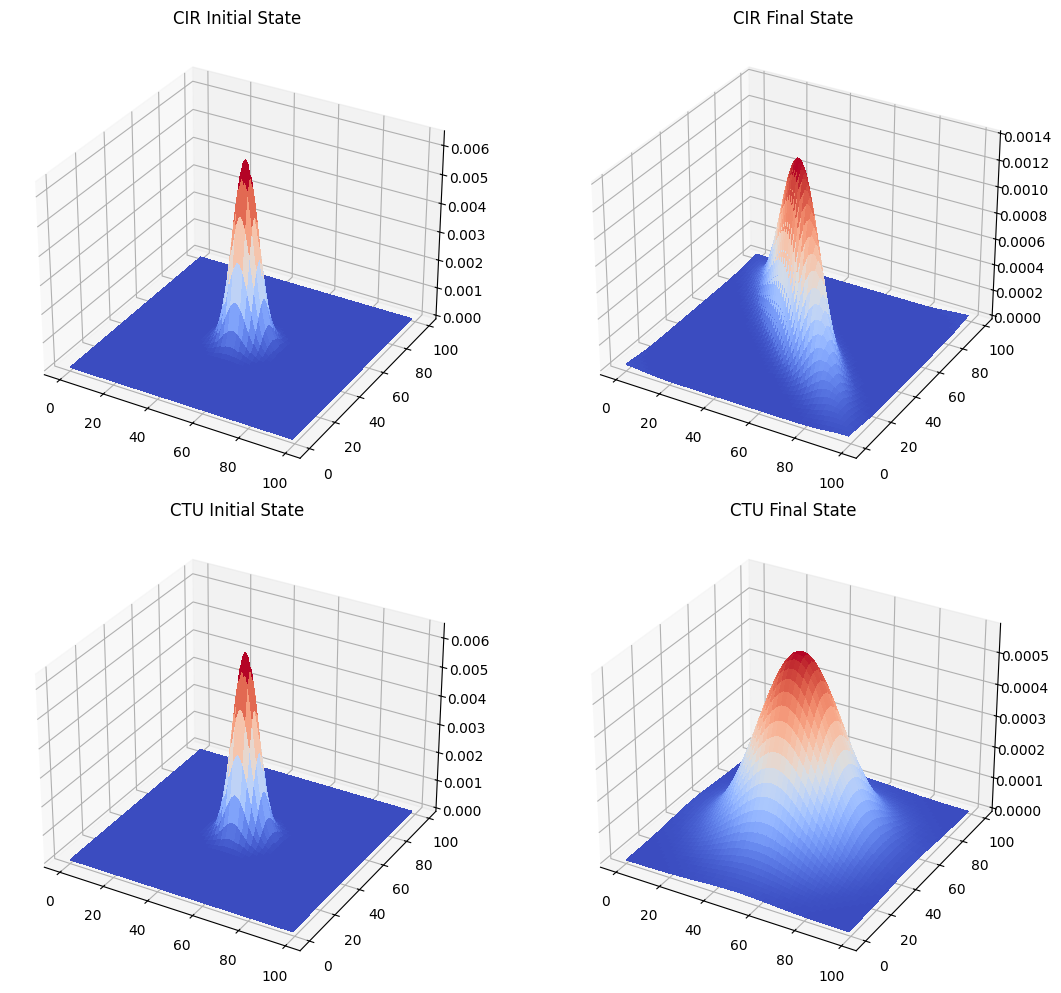

In [34]:
ca = 0.5
cb = 0.5

N = 100

tend =  1000

def evolve(rho, method):
    rhos = np.ndarray((tend,N,N))
    for i in range(tend):
        rhos[i] = rho
        rho = method(rho, ca, cb, N)
    return(rhos)

rho = np.ndarray((N,N))
rho[:] = 0

# create Gauss with sigma = 5
for i in range(N):
    for j in range(N):
        rho[i][j] = (1 / (2 * np.pi * 25)) * np.e ** (-((i-(N/2))**2 + (j-(N/2))**2)/(2*25))


CIR_rho = evolve(rho.copy(), CIR)
CTU_rho = evolve(rho.copy(), CTU)

x = np.arange(N)
y = np.arange(N)
X, Y = np.meshgrid(x, y)

fig, axs = plt.subplots(2, 2, subplot_kw={"projection": "3d"}, figsize=(12, 10))

# CIR start
axs[0, 0].plot_surface(X, Y, CIR_rho[0], cmap=cm.coolwarm, linewidth=0, antialiased=False)
axs[0, 0].set_title("CIR Initial State")

# CIR end
axs[0, 1].plot_surface(X, Y, CIR_rho[-1], cmap=cm.coolwarm, linewidth=0, antialiased=False)
axs[0, 1].set_title("CIR Final State")

# CTU start
axs[1, 0].plot_surface(X, Y, CTU_rho[0], cmap=cm.coolwarm, linewidth=0, antialiased=False)
axs[1, 0].set_title("CTU Initial State")

# CTU end
axs[1, 1].plot_surface(X, Y, CTU_rho[-1], cmap=cm.coolwarm, linewidth=0, antialiased=False)
axs[1, 1].set_title("CTU Final State")

plt.tight_layout()
plt.show()

def save_animation(rhos, filename):
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(8, 6))
    def update(frame):
        ax.clear()
        ax.plot_surface(X, Y, rhos[frame], cmap=cm.coolwarm, linewidth=0, antialiased=False)
        ax.set_zlim(np.min(rhos), np.max(rhos))
        ax.set_title(f"Time Step: {frame}")

    anim = FuncAnimation(fig, update, frames=range(0, tend, 10), interval=120)
    anim.save(filename, fps=15, extra_args=['-vcodec', 'libx264'])
    plt.close(fig)

save_animation(CIR_rho, 'CIR.mp4')
save_animation(CTU_rho, 'CTU.mp4')
